# Jaccard 임계값 분석

Step 2 중복 처리에서 사용한 Jaccard 임계값(현재 0.85)이 적절한지 평가하고 조정 근거를 마련한다.

## 진행 단계

| Step | 설명 |
|------|------|
| A | 모든 페어의 Jaccard 점수 계산 → 분포 히스토그램으로 봉우리/골짜기 확인 |
| B | 0.5–0.7 / 0.7–0.85 / 0.85–1.0 구간별 페어 무작위 샘플링 → 라벨링용 CSV 출력 |
| C | (라벨링 완료 후) 라벨링 CSV 다시 로드 → 임계값별 Precision/Recall 계산 |

**라벨링 작업은 Step B와 C 사이**에서 사람이 직접 한다. 추출된 CSV의 `label` 컬럼에 `dup` 또는 `unique`를 채워 넣은 뒤 저장하면 Step C가 그 결과를 읽어 평가한다.

---
## 0. 데이터 로드 + Step 2와 동일한 그룹핑

In [1]:
import re
import numpy as np
import pandas as pd
from itertools import combinations
from tqdm.auto import tqdm

INPUT_PATH = "reviews_step1_cleaned.csv"
TEXT_COL = "리뷰내용_clean"

df = pd.read_csv(INPUT_PATH, low_memory=False)
df['작성일'] = pd.to_datetime(df['작성일'], errors='coerce')
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)
print(f"로드 완료: {len(df):,}건")

로드 완료: 685,042건


In [2]:
# Step 0: 익명 처리 (Step 2와 동일)
df['작성자_norm'] = df['작성자'].astype(str)
mask_anon = df['작성자_norm'].str.strip() == '-'
df.loc[mask_anon, '작성자_norm'] = '_anon_' + df.loc[mask_anon].index.astype(str)

# Step 1: month 제외
df_main = df[df['리뷰타입'] != 'month'].copy()
print(f"month 제외 후: {len(df_main):,}건")

month 제외 후: 659,954건


In [3]:
# 24h 세션 분리 (Step 2와 동일)
df_main = df_main.sort_values(['작성자_norm', 'goodsNo', '작성일']).reset_index(drop=True)
g = df_main.groupby(['작성자_norm', 'goodsNo'])
prev_time = g['작성일'].shift(1)
time_diff_h = (df_main['작성일'] - prev_time).dt.total_seconds() / 3600
new_session = (prev_time.isna()) | (time_diff_h > 24)
df_main['세션'] = new_session.groupby(
    [df_main['작성자_norm'], df_main['goodsNo']]
).cumsum().astype(int)

# 그룹 크기
group_sizes = df_main.groupby(['작성자_norm', 'goodsNo', '세션']).size()
df_main = df_main.merge(
    group_sizes.rename('그룹크기').reset_index(),
    on=['작성자_norm', 'goodsNo', '세션'], how='left'
)

# 다중 그룹만 추출 (페어 비교 대상)
df_multi = df_main[df_main['그룹크기'] >= 2].copy()
print(f"다중 그룹 행: {len(df_multi):,}건")
print(f"다중 그룹 수: {df_multi.groupby(['작성자_norm', 'goodsNo', '세션']).ngroups:,}")

다중 그룹 행: 236,413건
다중 그룹 수: 102,196


---
## Jaccard 함수 (Step 2와 동일)

In [4]:
MIN_LEN_FOR_JACCARD = 15

def normalize_for_compare(s: str) -> str:
    return re.sub(r'[\s\.\,\!\?\~\^\;\:\-\_\(\)\[\]\"\']+', '', s)

def char_ngrams(s: str, n: int = 2) -> set:
    if len(s) < n:
        return {s} if s else set()
    return {s[i:i+n] for i in range(len(s) - n + 1)}

def jaccard_sim(s1: str, s2: str) -> float:
    if not s1 or not s2:
        return 0.0
    n1 = normalize_for_compare(s1)
    n2 = normalize_for_compare(s2)
    if len(n1) < MIN_LEN_FOR_JACCARD or len(n2) < MIN_LEN_FOR_JACCARD:
        return 1.0 if n1 == n2 else 0.0
    g1 = char_ngrams(n1, n=2)
    g2 = char_ngrams(n2, n=2)
    if not g1 or not g2:
        return 0.0
    return len(g1 & g2) / len(g1 | g2)

---
## Step A. 모든 페어의 Jaccard 점수 계산

각 다중 그룹 안에서 가능한 모든 (행 i, 행 j) 페어에 대해 Jaccard를 계산한다.
나중에 분포·샘플링·평가 모두 이 페어 테이블에서 가져다 쓴다.

In [5]:
def make_option_key(s, d):
    s_v = s if pd.notna(s) else None
    d_v = d if pd.notna(d) else None
    return (s_v, d_v)

df_multi['옵션키'] = [
    make_option_key(s, d) for s, d in zip(df_multi['구매사이즈'], df_multi['구매상세'])
]

# 그룹별 페어 만들기
pair_rows = []
groups = df_multi.groupby(['작성자_norm', 'goodsNo', '세션'], sort=False)

for (author, goods, sess), gdf in tqdm(groups, desc="페어 생성"):
    if len(gdf) < 2:
        continue
    idx_list = gdf.index.tolist()
    for i, j in combinations(idx_list, 2):
        ri = gdf.loc[i]
        rj = gdf.loc[j]
        sim = jaccard_sim(ri[TEXT_COL], rj[TEXT_COL])
        pair_rows.append({
            '작성자_norm': author,
            'goodsNo': goods,
            '세션': sess,
            '리뷰번호_a': ri['리뷰번호'],
            '리뷰번호_b': rj['리뷰번호'],
            '옵션_a': ri['옵션키'],
            '옵션_b': rj['옵션키'],
            '타입_a': ri['리뷰타입'],
            '타입_b': rj['리뷰타입'],
            '글자수_a': ri.get('한글_글자수', len(ri[TEXT_COL])),
            '글자수_b': rj.get('한글_글자수', len(rj[TEXT_COL])),
            '텍스트_a': ri[TEXT_COL],
            '텍스트_b': rj[TEXT_COL],
            'jaccard': sim,
            '옵션_같음': ri['옵션키'] == rj['옵션키'],
            '타입_같음': ri['리뷰타입'] == rj['리뷰타입'],
        })

df_pairs = pd.DataFrame(pair_rows)
print(f"\n전체 페어 수: {len(df_pairs):,}")
print(f"\nJaccard 통계:")
print(df_pairs['jaccard'].describe())

페어 생성:   0%|          | 0/102196 [00:00<?, ?it/s]


전체 페어 수: 170,061

Jaccard 통계:
count    170061.000000
mean          0.530925
std           0.438254
min           0.000000
25%           0.081633
50%           0.404762
75%           1.000000
max           1.000000
Name: jaccard, dtype: float64


### A-1. 분포 히스토그램

**보는 법**:
- 봉우리(peak) 두 개 사이에 골짜기(valley)가 있으면 그 위치가 좋은 임계값 후보
- 중간 영역(0.4~0.7)이 비어 있을수록 임계값 결정이 쉬움
- 중간 영역이 두꺼우면 어떤 임계값을 잡아도 잡음 / 누락이 발생함을 의미

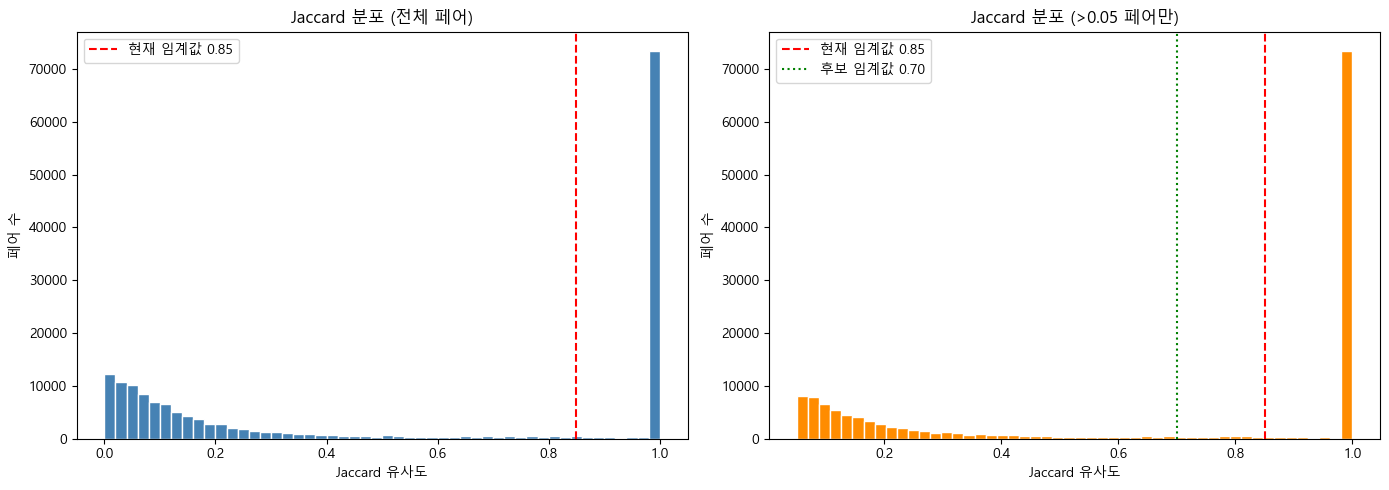

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (환경에 맞게 fallback)
for font_name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    if any(font_name in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = font_name
        break
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 분포
axes[0].hist(df_pairs['jaccard'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0.85, color='red', linestyle='--', label='현재 임계값 0.85')
axes[0].set_title('Jaccard 분포 (전체 페어)')
axes[0].set_xlabel('Jaccard 유사도')
axes[0].set_ylabel('페어 수')
axes[0].legend()

# 0 근처 제외 (대부분이 0에 몰려있어 잘 안 보일 수 있음)
mask_nonzero = df_pairs['jaccard'] > 0.05
axes[1].hist(df_pairs.loc[mask_nonzero, 'jaccard'], bins=50,
             color='darkorange', edgecolor='white')
axes[1].axvline(0.85, color='red', linestyle='--', label='현재 임계값 0.85')
axes[1].axvline(0.70, color='green', linestyle=':', label='후보 임계값 0.70')
axes[1].set_title('Jaccard 분포 (>0.05 페어만)')
axes[1].set_xlabel('Jaccard 유사도')
axes[1].set_ylabel('페어 수')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# 구간별 페어 수 (테이블)
bins = [0, 0.3, 0.5, 0.7, 0.85, 0.95, 1.01]
labels_ = ['0.0~0.3', '0.3~0.5', '0.5~0.7', '0.7~0.85', '0.85~0.95', '0.95~1.0']
df_pairs['구간'] = pd.cut(df_pairs['jaccard'], bins=bins, labels=labels_,
                          right=False, include_lowest=True)

dist = df_pairs['구간'].value_counts().sort_index()
print("[구간별 페어 수]")
print(dist)
print(f"\n전체: {len(df_pairs):,}")
print(f"현재 임계값(0.85) 이상: {(df_pairs['jaccard'] >= 0.85).sum():,}건 "
      f"({(df_pairs['jaccard'] >= 0.85).sum()/len(df_pairs)*100:.1f}%)")
print(f"후보 임계값(0.70) 이상: {(df_pairs['jaccard'] >= 0.70).sum():,}건 "
      f"({(df_pairs['jaccard'] >= 0.70).sum()/len(df_pairs)*100:.1f}%)")

[구간별 페어 수]
구간
0.0~0.3      80207
0.3~0.5       7206
0.5~0.7       4122
0.7~0.85      3117
0.85~0.95     1585
0.95~1.0     73824
Name: count, dtype: int64

전체: 170,061
현재 임계값(0.85) 이상: 75,409건 (44.3%)
후보 임계값(0.70) 이상: 78,526건 (46.2%)


In [12]:
(df_pairs[df_pairs['jaccard'] >=0.85].sum()) / (df_pairs.sum()) * 100

TypeError: 'Categorical' with dtype category does not support operation 'sum'